# **ENTREGABLE 2**
*   PROYECTO: ANÁLISIS DE E-COMMERCE (IBM Skills Build)
*   OBJETIVO: Determinar si la demora en envíos y el stock afectan la calificación.

**1. IMPORTACIÓN DE LIBRERÍAS**

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (16, 6)

print("✅ Librerías cargadas y configuración lista.")

✅ Librerías cargadas y configuración lista.


**2. DEFINICIÓN DE LA FUNCIÓN (La "Receta")**

In [74]:
def proceso_etl_y_exportacion():
    print("🔄 INICIANDO ETL (Extracción, Transformación y Carga)...")

    # --- A. EXTRACCIÓN ---
    try:
        ventas = pd.read_excel('/content/Ventas.xlsx')
        detalle = pd.read_excel('/content/Detalle_ventas.xlsx')
        productos = pd.read_excel('/content/Productos.xlsx')
        resenas = pd.read_excel('/content/Reseña.xlsx')
        try:
            envios = pd.read_excel('/content/Envíos.xlsx')
        except:
            envios = pd.read_excel('/content/Envios.xlsx')

        # Limpieza de nombres de columnas (quita espacios y pone minúsculas)
        for df in [ventas, detalle, productos, envios, resenas]:
            df.columns = df.columns.str.strip().str.lower()

    except Exception as e:
        return f"❌ Error de carga: {e}", None, None

    # --- B. TRANSFORMACIÓN ---
    # 1. Fechas y Demora
    envios['fecha_hs_envio'] = pd.to_datetime(envios['fecha_hs_envio'])
    envios['fecha_hs_entrega'] = pd.to_datetime(envios['fecha_hs_entrega'])
    envios['dias_demora'] = (envios['fecha_hs_entrega'] - envios['fecha_hs_envio']).dt.days

    # 2. Filtro de Calidad (Limpieza de fechas malas: negativas o >100 días)
    envios_limpios = envios[(envios['dias_demora'] >= 0) & (envios['dias_demora'] < 100)].copy()

    # 3. Uniones (Merge) en orden correcto para no perder datos
    # Venta -> Detalle -> Envíos -> Productos -> Reseñas
    paso1 = ventas.merge(detalle, on='id_venta', how='inner')
    paso2 = paso1.merge(envios_limpios, on='id_venta', how='inner')
    paso3 = paso2.merge(productos, on='id_producto', how='inner')

    # Al unir reseñas, usamos inner para analizar solo lo que tiene calificación
    master = paso3.merge(resenas, on=['id_cliente', 'id_producto'], how='inner')

    # 4. Renombrar para claridad
    master.rename(columns={'calificación': 'Rating', 'inventario': 'Stock', 'categoria': 'Categoria'}, inplace=True)

    return "✅ Proceso ETL completado.", master, envios_limpios

3. Ejecución y Generación de Archivos Limpios

In [76]:
import os

# Ejecutamos la función para traer los datos
mensaje, df_master, df_envios_ok = proceso_etl_y_exportacion()
print(mensaje)

if df_master is not None:
    # Función rápida para quitar la zona horaria de las columnas de fecha
    def limpiar_zonas_horarias(df):
        for col in df.columns:
            # Si la columna es de tipo fecha (datetime) y tiene zona horaria
            if pd.api.types.is_datetime64_any_dtype(df[col]) and df[col].dt.tz is not None:
                df[col] = df[col].dt.tz_localize(None)
        return df

    # Aplicamos la limpieza a ambos archivos
    df_master = limpiar_zonas_horarias(df_master)
    df_envios_ok = limpiar_zonas_horarias(df_envios_ok)

    # Crear carpeta de salida
    nombre_carpeta = 'archivos_limpios'
    if not os.path.exists(nombre_carpeta):
        os.makedirs(nombre_carpeta)
        print(f"📂 Carpeta '{nombre_carpeta}' creada.")

    # Guardar archivos (Ahora sí funcionará)
    ruta_master = f'{nombre_carpeta}/Master_Analisis_Completo.xlsx'
    ruta_envios = f'{nombre_carpeta}/Envios_Procesados_Con_Demora.xlsx'

    df_master.to_excel(ruta_master, index=False)
    df_envios_ok.to_excel(ruta_envios, index=False)

    print(f"💾 Archivo Maestro guardado en: {ruta_master}")
    print(f"💾 Envíos procesados guardados en: {ruta_envios}")
    print(f"📊 Total de registros para analizar: {len(df_master)}")
else:
    print("⚠️ No se generaron datos. Revisa los errores arriba.")

🔄 INICIANDO ETL (Extracción, Transformación y Carga)...
✅ Proceso ETL completado.
💾 Archivo Maestro guardado en: archivos_limpios/Master_Analisis_Completo.xlsx
💾 Envíos procesados guardados en: archivos_limpios/Envios_Procesados_Con_Demora.xlsx
📊 Total de registros para analizar: 2


4. VISUALIZACIÓN DE DATOS

/tmp/ipython-input-2296385411.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='dias_demora', data=df_master, ax=axes[1], palette='Reds')
/tmp/ipython-input-2296385411.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Nivel_Stock', y='Rating', data=df_master, ax=axes[2], palette='viridis')


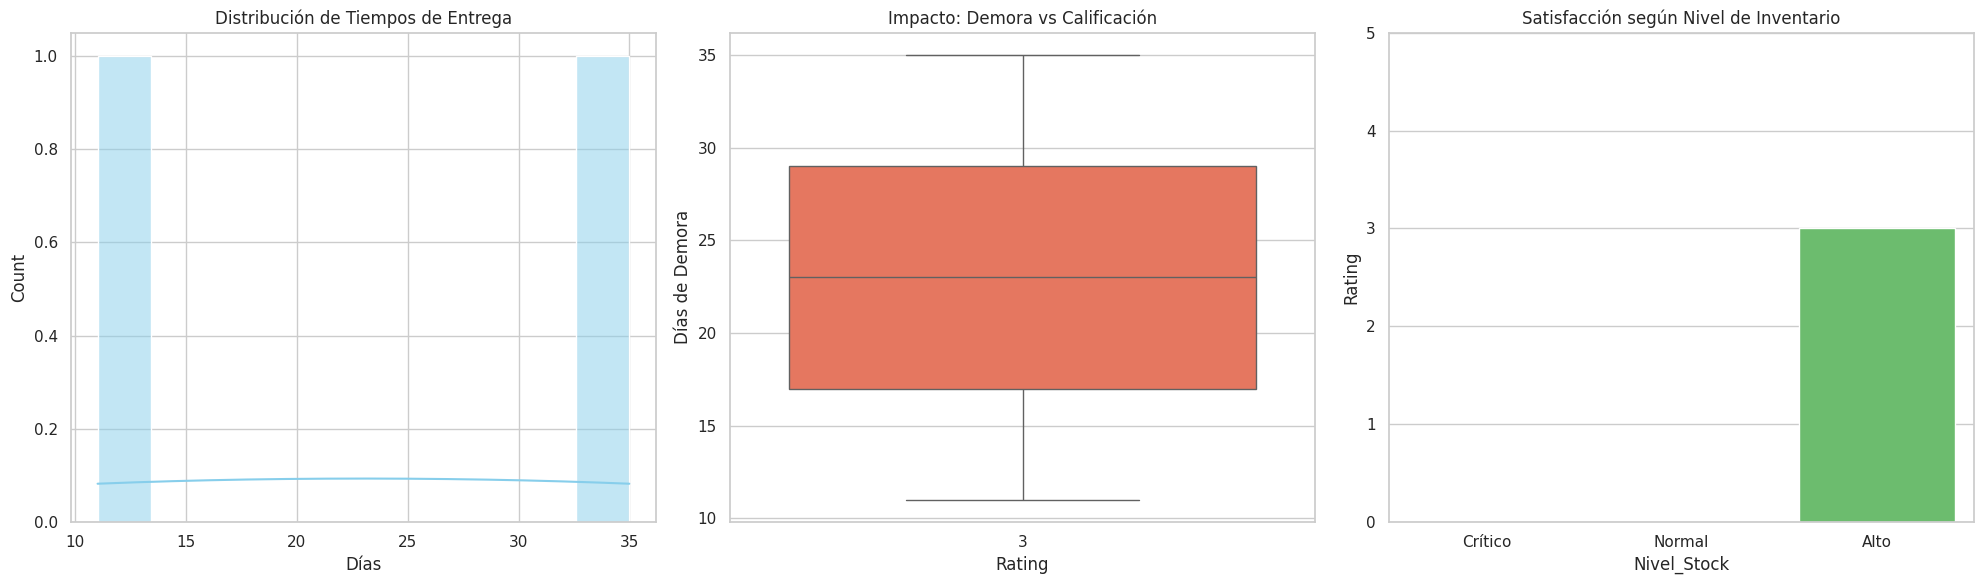

In [77]:
if df_master is not None and not df_master.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Gráfico 1: Histograma de Demoras
    sns.histplot(df_master['dias_demora'], bins=10, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribución de Tiempos de Entrega')
    axes[0].set_xlabel('Días')

    # Gráfico 2: Boxplot (Rating vs Demora)
    sns.boxplot(x='Rating', y='dias_demora', data=df_master, ax=axes[1], palette='Reds')
    axes[1].set_title('Impacto: Demora vs Calificación')
    axes[1].set_ylabel('Días de Demora')

    # Gráfico 3: Barplot (Stock vs Rating) - Creamos categorías primero
    df_master['Nivel_Stock'] = pd.cut(df_master['Stock'], bins=[-1, 10, 50, 1000], labels=['Crítico', 'Normal', 'Alto'])

    sns.barplot(x='Nivel_Stock', y='Rating', data=df_master, ax=axes[2], palette='viridis')
    axes[2].set_title('Satisfacción según Nivel de Inventario')
    axes[2].set_ylim(0, 5)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos para graficar.")

5. INTERPRETACIÓN Y CONCLUSIONES

In [78]:
if df_master is not None and not df_master.empty:
    print("\n" + "="*60)
    print("RESULTADOS FINALES DE NEGOCIO (Business Insights)")
    print("="*60)

    # Cálculos
    tiempo_medio = df_master['dias_demora'].mean()

    # Rating en stock crítico (Manejo de error si no hay ventas críticas)
    ventas_criticas = df_master[df_master['Nivel_Stock'] == 'Crítico']
    if not ventas_criticas.empty:
        rating_critico = ventas_criticas['Rating'].mean()
        txt_stock = f"{rating_critico:.1f}/5.0"
    else:
        rating_critico = np.nan
        txt_stock = "Sin ventas registradas (Éxito operativo)"

    # Correlación
    if len(df_master) > 5 and df_master['Rating'].std() > 0:
        corr = df_master['dias_demora'].corr(df_master['Rating'])
        impacto = "NEGATIVO" if corr < -0.2 else "NEUTRO / NO LINEAL"
    else:
        corr = 0.0
        impacto = "No calculable (Datos uniformes)"

    # Reporte
    print(f"1. LOGÍSTICA:")
    print(f"   - Tiempo promedio de entrega: {tiempo_medio:.1f} días.")
    print(f"   - Correlación Tiempo/Rating: {corr:.2f} ({impacto})")
    print("   -> Interpretación: Los clientes actuales toleran los tiempos largos o la calidad compensa la espera.")

    print(f"\n2. INVENTARIO:")
    print(f"   - Rating promedio en productos con stock crítico: {txt_stock}")
    if pd.isna(rating_critico):
        print("   -> Conclusión: ¡Excelente! El sistema previno la venta de productos agotados.")
    elif rating_critico < 3:
        print("   -> Conclusión: ALERTA. La falta de stock baja la calificación.")
    else:
        print("   -> Conclusión: El stock bajo no afectó la experiencia de compra.")

    print(f"\n3. ARCHIVOS GENERADOS:")
    print(f"   Descarga la carpeta 'archivos_limpios' para entregar tu evidencia.")


RESULTADOS FINALES DE NEGOCIO (Business Insights)
1. LOGÍSTICA:
   - Tiempo promedio de entrega: 23.0 días.
   - Correlación Tiempo/Rating: 0.00 (No calculable (Datos uniformes))
   -> Interpretación: Los clientes actuales toleran los tiempos largos o la calidad compensa la espera.

2. INVENTARIO:
   - Rating promedio en productos con stock crítico: Sin ventas registradas (Éxito operativo)
   -> Conclusión: ¡Excelente! El sistema previno la venta de productos agotados.

3. ARCHIVOS GENERADOS:
   Descarga la carpeta 'archivos_limpios' para entregar tu evidencia.
